<center>
    <h1 style = "color:blue" "align=center"; >ISAT341-Data Science and Machine Learning</h1>
</center>
<center>
    <h2 style = "color:green" "align=center"; >Project: Machine Learning Confidential Sensor Data</h2>
</center>
<center>
    <img src="images/machine_learning.jpg" width=200; height=200>
</center>
<center>
<h2 style ="color:red" "align=center";>Working with <i>real-world</i> datasets</h2>
</center>
<center>
    <h3>by Joshua Brewington and Alex Roy</h3>
    </center>

<h1>Ojectives</h1>
To demonstrate the ability to complete an end-to-end data science / machine learning project using real-world data by following and implementing the main machine learning checklist steps that lead to a solution, namely:

- Frame the problem and look at the big picture.
- Get the data.
- Explore the data to gain insights.
- Prepare the data to expose the underlying data patterns to Machine Learning alogorithms.
- Fine-tune your models and combine them into a great solution.
- Present your solution.
- Launch, monitor, and maintain your system

<h2 style="color:purple">Frame the Problem</h2>
<center>
    <img src="images/sensor_array.jpg" width=300; height=300>
</center>

<center>
    <h3>Sensor Data</h3>
    </center>

The data source as well as the exact nature of the data is confidential. Each data instance contains 12 real-valued input attributes. Each input attribute represents a sensor desinged to detect the presence of one of two groups of substances. As an alternative, the sensor readings may represent a 'false alarm'.

- Substance 1 is represented by the value 'one' in the class attribute column.
- Substance 2 is represented by the value 'two' in the class attribute column.
- Substance 3 is represented by the value 'three' in the class attribute column.

The problem is framed as a **Supervised learning** problem: Predict the class of a substance from sensor data using the given measurements in the dataset.

<center>
    <h2 style="color:purple">Project Analysis Starts Here!</h2>
    </center>
<center>
    <h3 style="color:red">DO NOT remove the TO DO labels and your Notebook MUST have the same numbering indicated here</h3>
    </center>

<h2>Import Packages</h2>

In [1]:
# import packages
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
np.set_printoptions(precision=3, suppress=True)

Here we imported the packages needed to load the dataset and manipulate with Numpy.

<h2 style="color:green">Exploratory Data Analysis</h2>

### 1) TO DO: Use Pandas to load your data into a dataframe

Display the first ten rows after you load the data.

In [2]:
#import csv
import pandas as pd

df = pd.read_csv('data/Sensor_Data_Confidential_341Project_DataSet5.csv', encoding='utf')
df.head(10)

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Input 9,Input 10,Input 11,Input 12,class
0,1.473,2.311,3.179,2.666,0.27950,0.27710,0.22340,0.18550,0.2539,1.138,1.1110,4.712,one
1,1.460,2.377,3.214,2.920,0.25270,0.30640,0.02563,0.19650,0.3027,1.213,1.0270,5.463,one
2,1.552,2.164,3.064,2.745,0.28200,0.21000,0.17210,0.19290,0.2100,1.221,1.0580,5.332,one
3,1.605,2.228,3.149,2.834,0.29170,0.36130,0.20870,0.12940,0.2734,1.144,1.0620,4.829,one
4,1.534,2.114,3.309,2.976,0.21000,0.25020,0.22580,0.17700,0.2039,1.254,1.1120,5.734,one
5,1.796,2.262,3.180,2.888,0.29660,0.14770,0.16240,0.28200,-9999.0000,1.172,1.0300,4.861,one
6,1.566,2.323,3.469,2.711,0.24170,0.05371,0.21120,-0.02686,0.2197,1.158,0.9924,4.780,one
7,1.425,2.152,3.287,2.781,0.29910,0.20750,0.10380,0.11470,0.2698,1.271,1.1150,5.662,one
8,1.595,2.271,3.323,2.743,0.17330,0.19650,0.16850,0.05859,0.2051,1.290,1.0330,5.145,one
9,1.628,2.211,3.176,2.710,0.08423,0.18920,0.27830,0.16850,0.3491,1.155,1.0080,5.613,one


Here we loaded the first 10 rows of data starting at the index 0 for the first instance. Each data instance has 12 real-valued input attributes that represent a sensor designated to detecting the presence of one of two groups of substances.

### 2) TO DO: Use the dataframe describe method *dataframe.describe()* to display some summary statistics

In [3]:
# use the method .describe() set to the variable 'df'
df.describe()

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Input 9,Input 10,Input 11,Input 12
count,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000,2064.000000
mean,-102.944836,-109.711795,-111.319884,-67.994856,-124.949039,-105.066162,-81.658039,-125.587986,-100.835192,-74.740051,-85.312925,-78.599944
std,1027.427211,1050.057089,1072.729741,849.911071,1115.540299,1027.206775,903.995215,1115.467928,1003.772889,877.403031,930.088695,904.281076
min,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
25%,3.058500,0.817600,4.848250,3.998250,0.462600,0.649400,0.308800,0.188000,0.423600,1.379000,1.089000,0.789800
50%,4.082000,1.353000,5.336000,5.041000,0.806300,1.634500,0.565200,0.302700,0.694600,1.996000,1.285500,4.915000
75%,4.504000,2.354250,5.591250,5.642750,1.400750,2.159000,0.959800,0.491900,1.234250,4.974000,1.865250,5.403000
max,5.105000,4.675000,5.944000,6.013000,2.754000,3.638000,2.446000,1.199000,2.561000,5.312000,5.640000,20.000000


Here we got a statistical summary of all the input attributes. We gathered count, mean, std, min, 25%, 50%, 75%, and max.

<h2 style="color:purple">Comments on above summary of data</h2>
 
 *Examine the data and note that when a sensor temporarily goes offline, it records a BAD data value of -9999.* This can be seen in the minimum recored values for each sensor. Before we continue our preliminary data analysis, this bad must be removed.
 
You should also take note of the **count, mean, standard deviation** and the **maximum** data values for each sensor. The bad data value recordings when the sensors go *offline* have a large impact on these simple descriptive statistical summaries. Also, the wide range of the data values will require some sort of scaling of the data before training a machine learning model.

Finally, the class labels are not numeric but are strings ('one', 'two' and 'three') that we call categorical class labels. We will need to convert them to integers before we feed them to a classifier.

<h2 style="color:green">Data Cleansing</h2>

### 3) TO DO: Display the shape of your dataframe data in the cell below

In [4]:
print('Shape of the data : {}'.format(df.shape))

# Here we are printing the shape of the data in the X and y variables.

Shape of the data : (2064, 13)


Here we displayed the shapes of the data for the y vector and the 12 different input attributes. There are 2064 rows of data for both X and y and 12 columns for X.

### 4) TO DO: Display the shape of your dataframe data in the cell below

The bad data can be located and replaced using pandas and numpy. In the cell below, use code to find and replace the bad data (-9999 values) with numpy nan values (*nan means not a number*). Then use the dataframe to drop the rows with the nan signatures. This may significantly reduce your dataset so you should display the shape of the data to see its new size. Also, again, display the first ten rows of the data with the dataframe.

- **Enter your code in the cell below to implement the drop, replace and display.**
- **Enter your code in the cell immediately following the output of the dataframe display to show the new shape of data in the dataframe.**

In [5]:
df = df.replace(-9999.0,np.nan)
df = df.dropna()
df.head(10)

# Here we replaced the bad data with numpy nan values.
# Then we dropped the bad data (-9999) with the method dropna().
# Then we displayed the first 10 rows of data.

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Input 9,Input 10,Input 11,Input 12,class
0,1.473,2.311,3.179,2.666,0.27950,0.27710,0.22340,0.18550,0.2539,1.138,1.1110,4.712,one
1,1.460,2.377,3.214,2.920,0.25270,0.30640,0.02563,0.19650,0.3027,1.213,1.0270,5.463,one
2,1.552,2.164,3.064,2.745,0.28200,0.21000,0.17210,0.19290,0.2100,1.221,1.0580,5.332,one
3,1.605,2.228,3.149,2.834,0.29170,0.36130,0.20870,0.12940,0.2734,1.144,1.0620,4.829,one
4,1.534,2.114,3.309,2.976,0.21000,0.25020,0.22580,0.17700,0.2039,1.254,1.1120,5.734,one
6,1.566,2.323,3.469,2.711,0.24170,0.05371,0.21120,-0.02686,0.2197,1.158,0.9924,4.780,one
7,1.425,2.152,3.287,2.781,0.29910,0.20750,0.10380,0.11470,0.2698,1.271,1.1150,5.662,one
8,1.595,2.271,3.323,2.743,0.17330,0.19650,0.16850,0.05859,0.2051,1.290,1.0330,5.145,one
9,1.628,2.211,3.176,2.710,0.08423,0.18920,0.27830,0.16850,0.3491,1.155,1.0080,5.613,one
10,1.583,2.253,3.278,2.854,0.14890,0.10990,0.22830,0.07324,0.2173,1.135,1.1120,5.549,one


we used the dropna() nethod to drop bad data. When we displayed the first 10 rows of the data it was visible in index position 5 and input 9, there is bad data. In the cleaned up version of the data, it is present that the istannce for index 5 is gone.

In [6]:
# shape of data in dataframe after cleansing.

print('Shape of the data : {}'.format(df.shape))

Shape of the data : (1826, 13)


Here we display the new shape of the data after we manipulated it with the .dropna() method. Originally, the shape of the data was (2064, 13). Now, the cleaned data's shape is (1826, 13). We dropped the bad rows of data, which explains the deviation from 2064 to 1826.

### 5) TO DO: Use pandas correlation method to find the two features (inputs) with the highest correlation

**Enter your answers in the cell immediately following the output correlation table**

In [7]:
df.corr()
#This is showing the statistical correlation between collumns.

,Input 1,Input 2,Input 3,Input 4,Input 5,Input 6,Input 7,Input 8,Input 9,Input 10,Input 11,Input 12
Input 1,1.000000,-0.527248,0.932390,0.938750,0.748763,0.900299,0.701600,0.675776,0.722770,0.692099,0.464854,-0.160311
Input 2,-0.527248,1.000000,-0.463356,-0.505046,-0.416400,-0.614186,-0.426394,-0.437816,-0.435743,-0.449897,-0.352147,-0.091390
Input 3,0.932390,-0.463356,1.000000,0.884079,0.643788,0.813403,0.596152,0.574708,0.630974,0.605835,0.403812,-0.160420
Input 4,0.938750,-0.505046,0.884079,1.000000,0.812194,0.877337,0.734622,0.727402,0.802189,0.764233,0.537204,-0.159417
Input 5,0.748763,-0.416400,0.643788,0.812194,1.000000,0.834460,0.905794,0.901688,0.972590,0.885527,0.742445,-0.183917
Input 6,0.900299,-0.614186,0.813403,0.877337,0.834460,1.000000,0.772869,0.764765,0.825776,0.827059,0.657962,-0.181238
Input 7,0.701600,-0.426394,0.596152,0.734622,0.905794,0.772869,1.000000,0.944429,0.845032,0.810357,0.536046,-0.225150
Input 8,0.675776,-0.437816,0.574708,0.727402,0.901688,0.764765,0.944429,1.000000,0.858171,0.815908,0.566306,-0.234747
Input 9,0.722770,-0.435743,0.630974,0.802189,0.972590,0.825776,0.845032,0.858171,1.000000,0.880231,0.805716,-0.192808
Input 10,0.692099,-0.449897,0.605835,0.764233,0.885527,0.827059,0.810357,0.815908,0.880231,1.000000,0.720474,-0.168878


**Your Answer:** Input 5 and Input 9

<h2 style="color:green">Data Visualization</h2>

### 6) TO DO: Plot bar charts using pandas dataframe (plot the mean value of the sensors)

The mean values are: 
Input 1     3.680058
Input 2     1.727913
Input 3     5.009482
Input 4     4.709107
Input 5     1.015576
Input 6     1.525255
Input 7     0.700818
Input 8     0.372550
Input 9     0.904062
Input 10    2.779109
Input 11    1.886693
Input 12    3.772419
dtype: float64


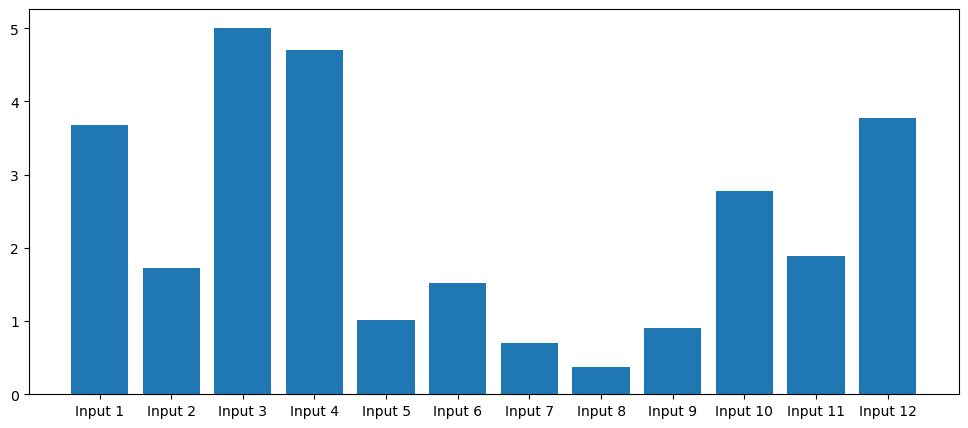

In [8]:
# get column names
columns = df.columns.tolist()

# exclude last column (class)
features = len(columns)-1
columns=columns[:features]

# get and print the mean values for all sensors
print('The mean values are: \n{}'.format(df.mean(numeric_only=True)))

# store mean values
mean_values=df[:].mean(numeric_only=True)

# Plot the data with bar charts
plt.figure(figsize=(12,5))
plt.bar(columns, mean_values)
plt.show()

Here we plotted the inputs' mean values in a bar chart.

<h3 style="color:green">Data Preprocessing</h3>

### 7) TO DO: Create Feature Matrix and Target Vector

**"Features"** are also known as predictors, inputs, or attributes. The **"response"** is also known as the target, label, or output.

<h4 style="color:orange"><i>complete in cell below

In [9]:
# The target vector is set to the variable 'y'.
#It is also known as a 'response'.
y=df['class']

# The inputs are features
X=df[['Input 1','Input 2','Input 3','Input 4','Input 5','Input 6','Input 7',
    'Input 8','Input 9','Input 10','Input 11','Input 12']]
print(y)
print(X)

0       one
1       one
2       one
3       one
4       one
       ... 
2059    two
2060    two
2061    two
2062    two
2063    two
Name: class, Length: 1826, dtype: object
      Input 1  Input 2  Input 3  Input 4  Input 5  Input 6  Input 7  Input 8  \
0       1.473    2.311    3.179    2.666   0.2795   0.2771  0.22340  0.18550   
1       1.460    2.377    3.214    2.920   0.2527   0.3064  0.02563  0.19650   
2       1.552    2.164    3.064    2.745   0.2820   0.2100  0.17210  0.19290   
3       1.605    2.228    3.149    2.834   0.2917   0.3613  0.20870  0.12940   
4       1.534    2.114    3.309    2.976   0.2100   0.2502  0.22580  0.17700   
...       ...      ...      ...      ...      ...      ...      ...      ...   
2059    3.682    1.301    4.939    4.453   0.4895   0.7922  0.23190  0.05005   
2060    3.412    1.293    4.949    4.199   0.4578   0.9521  0.21360  0.23070   
2061    3.640    1.284    5.111    4.460   0.5786   0.8020  0.26980  0.31740   
2062    3.746    1.261    5

Here we displayed the feature matrix and target vector.

### 8) TO DO: Convert the features dataframe to a numpy array

<h4 style="color:orange"><i>complete in cell below</h4>

In [10]:
# Use the values property

y=df['class'].values
X=df[['Input 1','Input 2','Input 3','Input 4','Input 5','Input 6','Input 7',
    'Input 8','Input 9','Input 10','Input 11','Input 12']].values

# Use the to_numpy() method of the dataframe to cast the objects

y=df['class'].to_numpy()
X=df[['Input 1','Input 2','Input 3','Input 4','Input 5','Input 6','Input 7',
    'Input 8','Input 9','Input 10','Input 11','Input 12']].to_numpy()

# Use the numpy to directly covert the dataframe object to numpy arrays as in import numpy as np

y=np.array(df['class'])
X=np.array(df[['Input 1','Input 2','Input 3','Input 4','Input 5','Input 6','Input 7',
    'Input 8','Input 9','Input 10','Input 11','Input 12']])

print(y)
print(X)

['one' 'one' 'one' ... 'two' 'two' 'two']
[[1.473 2.311 3.179 ... 1.138 1.111 4.712]
 [1.46  2.377 3.214 ... 1.213 1.027 5.463]
 [1.552 2.164 3.064 ... 1.221 1.058 5.332]
 ...
 [3.64  1.284 5.111 ... 1.46  1.118 4.867]
 [3.746 1.261 5.049 ... 1.482 1.128 5.627]
 [3.959 1.108 5.422 ... 1.595 1.244 5.623]]


Here we converted the features dataframe into a numpy array. We first called the values property, then we used the to_numpy() method to cast the ojects. After that we then used numpy to convert the dataframe to numpy arrays.

### 9) TO DO: Label Encoding

Transform the categorical labels into integers using the cihit-learn label encoder

**Enter your code in the cell below**

In [11]:
# import label encoder
from sklearn.preprocessing import LabelEncoder

# instanstiate integer encoder
label_encoder = LabelEncoder()

# encode the class labels
y_encoded = label_encoder.fit_transform(y)

# print the categorical class labels we encoded (note the underscore!)
print(y_encoded)

# print a few encoded values using python slice
print(y_encoded[:5])

# print the shape of the encoded classes
print('encoded shape:',y_encoded.shape)

[0 0 0 ... 2 2 2]
[0 0 0 0 0]
encoded shape: (1826,)


The first line of the output is the categorical class labels we encoded. The second line of the output was the first few encoded values using python splice. The last line of the output is the endoded shape of the clases. The class labels have been presented as integers and the shape is (1826, ). There are 1826 rows.

### 10) TO DO: Split the data into Training and testing Sets

Skitkit learn contains a function called the **train_test_split** function that will randomly shuffle the dataset and then splits it into two datasets: a  **training set** used to build the model and a **test set** to assess and evaluate how well the model works on unseen data (also called out-of-sample data).

### *Use a 80% / 20% train/test split for this project.*

NOTE: You **must** use the encoded class labels in this part

**Enter your code in the next TWO cells below**

In [12]:
from sklearn.model_selection import train_test_split

#test_size=.20 means the test consists of 20% of the data
X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2,random_state=0)

In [13]:
print('X_train Shape of the data : {}'.format(X_train.shape))
print('y_train Shape of the data : {}'.format(y_train.shape))

# This displays the shape of the training sets

print('X_test Shape of the data : {}'.format(X_test.shape))
print('y_test Shape of the data : {}'.format(y_test.shape))

# This displays the shape of the testing sets

X_train Shape of the data : (1460, 12)
y_train Shape of the data : (1460,)
X_test Shape of the data : (366, 12)
y_test Shape of the data : (366,)


Here is the shape of the training and testing sets after we split into an 80/20% ratio.

<h2 style="color:green">Scale the Data</h2>

<h3 style="color:red">IMPORTANT: Standardizing the features:</h3>

Standardization of datasets (feature scaling) is a common requirement for many machine learning and optimazation algoritms implemented in scitkit-learn; they might behave badly if the individual features do not more or less look like standard normally distributed data, i.e., Gaussian with zero mean and unit variance.

### 12) TO DO: Let's use the StandardScaler from Scitkit-learn to transform (*scale*) our feature

#### Enter your code in the cell below

In [14]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

#### A comment on what the above code does

- Using the preceding code, we loaded the StandardScaler class from the preprocessing module and initialized a new StandardScaler object that we assigned to the variable sc.
- Using the fit method, StandardScaler estimated the parameters μ (sample mean) and (standard deviation) for each feature dimension from the training data.
- By calling the transform method, we then standardized the training data using those estimated parameters μ and sigma.
- Note that we used the same scaling parameters to standardize the test set so that both the values in the training and test dataset are comparable to each other.

#### IMPORTANT: So from this point forward you *must* use the *scaled* training and testing data

<h2 style="color:green">Model Building</h2>

#### Train multiple Machine Learning models during same session. You will use three algorithms from previous labs.

1. K-Nearest Neighbor (with k=10, k=50, k=200)
2. Logistic Regression
3. Linear Support Vector Classifier

During the evaluation phase you must predict class member propbabilities and comment on what they mean.This means that scikit-learn’s linear support vector classifier cannot be used for those prodictions since this model does not have a method to predict class membership probabilities, but like the other models, it does have the same *predict* method.

- You MUST properly use model evaluation metrics (accuracy, confusion matrix, etc.)
- Two of your models (KNN and Logistic Regression MUST predict class membership probabilities and associated class label names

<h2 style="color:green">Build a KNN CLassification Model for K = 10, 50 and 200</h2>

### 13) TO DO: In the sections below you should build and train the actual machine learning model.

#### In the cell below: enter the code to import, instantiate, fit, predict and test the model's performance (accuracy) for the K-Nearest Neighbor Model in SciKit-Learn for K= 10, 50 and 200. 
This should be completed in *ONE cell using a loop, etc.*

In [15]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

for k in [10,50,200]:
    knn=KNeighborsClassifier(n_neighbors=k)
    print(knn)
    knn.fit(X_train,y_train)
    y_pred=knn.predict(X_test)  
    print('Test accuracy (using knn.score()) for k = {0} is:{1:0.2f}'.format(k,knn.score(X_test,y_test)))
    print("Model's Predictive Accuracy for k = {0} is:{1:.2f}".format(k,metrics.accuracy_score(y_test,y_pred)))
    print('Misclassified samples for k = {0} are {1}\n'.format(k,(y_pred != y_test).sum()))
    
    classifier = knn
    # Here we set classifier equal to knn for fitting purposes.

KNeighborsClassifier(n_neighbors=10)
Test accuracy (using knn.score()) for k = 10 is:0.98
Model's Predictive Accuracy for k = 10 is:0.98
Misclassified samples for k = 10 are 7

KNeighborsClassifier(n_neighbors=50)
Test accuracy (using knn.score()) for k = 50 is:0.93
Model's Predictive Accuracy for k = 50 is:0.93
Misclassified samples for k = 50 are 24

KNeighborsClassifier(n_neighbors=200)
Test accuracy (using knn.score()) for k = 200 is:0.86
Model's Predictive Accuracy for k = 200 is:0.86
Misclassified samples for k = 200 are 51



Here we created a K-NN model for the k values of 10, 50, 200.

### Predicting class-membership probabilities

Scitkit-Learn has a method that allows prediction of class member probabilities.

- The probability that training examples belong to a certain class can be computed using the **predict_proba** method. For example, we can predict the probabilities of the first three samples in the test set as follows (NOTE: X_test_std[:3. :] means get the first 3 rows and the associated columns from the test dataset X_test):

> classifier.predict_proba(X_test_std[:3, :]) where classifier is either **K-NN or Logistic Regression**

In the cells below, your must predict the **class-membership probabilities** for each specified **SINGLE ROW OF DATA**

Also, you should recall that the label encoding that we implemented earlier resulted in the mapping:

**class membership label indices after encoding**

    0 = 'one' (the Substance is Substance 1)
    1 = 'three' (false alarm)
    2 = 'two' (The Substance is Substance 2)
    
### 14) TO DO: class-membership probability

Predict the class membership probability by using the row with **index = 10** from the X_test_std data. Make sure your print statement uses a complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

**Enter your code in the cell below.**

In [16]:
predicted_proba = classifier.predict_proba(X_test_std[10].reshape(1,-1))
predicted_class = classifier.predict(X_test_std[10].reshape(1,-1))
# We reshaped the array

print("For row index = 10, the predicted class-membership probabilities are:", predicted_proba[0])
print("The predicted class for row index 10 is:", predicted_class[0])
print("The actual class-memberships:", y_test[10])

For row index = 10, the predicted class-membership probabilities are: [1. 0. 0.]
The predicted class for row index 10 is: one
The actual class-memberships: two


These are the predicted probabilities for each class membership for index = 10.

### 15) TO DO: class-membership probability

Predict the class membership probability by using the a row with **index = 125** from the X_test_std data. Make sure your print statement uses a complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

**Enter your code in the cell below.**

In [17]:
predicted_proba = classifier.predict_proba(X_test_std[125].reshape(1,-1))
predicted_class = classifier.predict(X_test_std[125].reshape(1,-1))
# We reshaped the array

print("For row index = 125, the predicted class-membership probabilities are:", predicted_proba[0])
print("The predicted class for row index 125 is:", predicted_class[0])
print("The actual class-memberships:", y_test[125])

For row index = 125, the predicted class-membership probabilities are: [1. 0. 0.]
The predicted class for row index 125 is: one
The actual class-memberships: two


These are the predicted probabilities for each class membership for index = 125.

### 16) TO DO: class-membership probability

Predict the class membership probability by using the a row with **index = 200** from the X_test_std data. Make sure your print statement uses a complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

**Enter your code in the cell below.**

In [18]:
predicted_proba = classifier.predict_proba(X_test_std[200].reshape(1,-1))
predicted_class = classifier.predict(X_test_std[200].reshape(1,-1))
# We reshaped the array

print("For row index = 200, the predicted class-membership probabilities are:", predicted_proba[0])
print("The predicted class for row index 200 is:", predicted_class[0])
print("The actual class-memberships:", y_test[200])

For row index = 200, the predicted class-membership probabilities are: [1. 0. 0.]
The predicted class for row index 200 is: one
The actual class-memberships: one


These are the predicted probabilities for each class membership for index = 200.

<h3 style="color:green">Build a Logistic Regression Model</h3>

### 17) TO DO: scitkit-learn Logistic Regression for this lab

**Import and instantiate the *Logistic Regression* Model in ScitKit-Learn is in the cell below**

In [19]:
from sklearn.linear_model import LogisticRegression
# Here we import the logistic regreesion model from scitkit-learn.

The logistic regression model has been imported.

### 18) TO DO: Train the mdoel by calling the model's fit function

Now that the model has been instantiated (created) it still needs to be trained (fitted) to the training dataset. **Enter your code below to fit the model to the training dataset**

In [20]:
logr = LogisticRegression(solver='newton-cg',
                       multi_class='multinomial',
                       random_state=0)
logr.fit(X_train, y_train)

# The x and y training datasets were fit to the LogisticRegression package

LogisticRegression(multi_class='multinomial', random_state=0,
                   solver='newton-cg')

Here we fit the datasets to the logistic regression model with logr.fit().

### 19) TO DO: Evaluate the Logistic Regression Model

Use the test set to create the model's predictions. Name the prediction vector **y_pred** as in previous notebooks.

**Enter your code in the cell below:**

In [21]:
y_pred = logr.predict(X_test)
print("Test set predictions:\n {}".format(y_pred))
# These lines of code are displaying the test set predictions.
# They are class values.

Test set predictions:
 ['three' 'three' 'one' 'one' 'three' 'three' 'one' 'two' 'one' 'one' 'two'
 'two' 'two' 'one' 'three' 'one' 'two' 'one' 'three' 'two' 'three' 'one'
 'two' 'two' 'one' 'one' 'two' 'three' 'three' 'one' 'two' 'two' 'two'
 'one' 'two' 'two' 'one' 'one' 'two' 'two' 'one' 'three' 'one' 'three'
 'three' 'three' 'two' 'two' 'three' 'one' 'three' 'three' 'one' 'one'
 'three' 'one' 'two' 'two' 'one' 'one' 'one' 'two' 'one' 'one' 'two' 'two'
 'one' 'two' 'one' 'two' 'one' 'three' 'one' 'one' 'two' 'three' 'one'
 'one' 'two' 'three' 'three' 'one' 'three' 'two' 'two' 'one' 'two' 'two'
 'three' 'one' 'one' 'one' 'two' 'two' 'one' 'two' 'one' 'two' 'two' 'two'
 'one' 'three' 'one' 'two' 'one' 'two' 'two' 'one' 'three' 'two' 'two'
 'two' 'one' 'one' 'one' 'one' 'three' 'one' 'two' 'one' 'three' 'three'
 'one' 'one' 'two' 'two' 'two' 'three' 'two' 'one' 'one' 'three' 'one'
 'three' 'two' 'one' 'two' 'two' 'two' 'three' 'two' 'two' 'one' 'two'
 'two' 'two' 'two' 'two' 'one' 'one'

We tested for the model's predictions with the vector 'y_pred'.

### 20) TO DO: Evaluate the Logistic Regression Model's Performance

Use ScitKit Learn's built-in scoring method to evaluate the model's performace accuracy.

**Enter your code below:**

In [22]:
print('Test accuracy: {0:0.2f}'.format(logr.score(X_test, y_test)))
# Here we tested for accuracy of the model

Test accuracy: 0.98


Here we tested for the model's accuracy with the built-in scoring method.

#### Predicting class-membership probabilities using the Logistic Regression Model

### 21) TO DO:class-membership probability

Predict the class membership probability by using the a row with **index = 10** from the X_test_std data. Make sure your print statement uses a complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

**Enter your code in the cell below.**

In [23]:
print('The predicted probability for index {} is {}'
      .format(10, logr.predict_proba(X_test[10].reshape(1,-1))))
print("The actual class-memberships:", y_test[10])

# This is the predicted probability for one row of data.

The predicted probability for index 10 is [[0.129 0.    0.871]]
The actual class-memberships: two


These are the predicted probabilities for each class membership for index = 10.

### 22) TO DO:class-membership probability

Predict the class membership probability by using the a row with **index = 125** from the X_test_std data. Make sure your print statement uses a
complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

**Enter your code in the cell below.**

In [35]:
print('The predicted probability for index {} is {}'
      .format(125, logr.predict_proba(X_test[125].reshape(1,-1))))
print("The actual class-memberships:", y_test[125])

# This is the predicted probability for one row of data.

The predicted probability for index 125 is [[0.005 0.    0.995]]
The actual class-memberships: two


These are the predicted probabilities for each class membership for index = 125.

### 23) TO DO:class-membership probability

Predict the class membership probability by using the a row with **index = 200** from the X_test_std data. Make sure your print statement uses a
complete sentence and be sure to compare your prediction with the correct answer using the corresponding row from the test set labels, y_test.

**Enter your code in the cell below.**

In [36]:
print('The predicted probability for index {} is {}'
      .format(200, logr.predict_proba(X_test[200].reshape(1,-1))))
print("The actual class-memberships:", y_test[200])

# This is the predicted probability for one row of data.

The predicted probability for index 200 is [[0.869 0.    0.131]]
The actual class-memberships: one


These are the predicted probabilities for each class membership for index = 200.

<h3 style="color:green">Build Linear Support Vector Classifier Model</h3>

### 24) TO DO:scitkit-learn Linear Support Vector Classifier for this lab

**Import and instantiate the Linear Support Vector Classifier Model in ScitKit-Learn is in the cell below**